In [26]:
words = open(
    r"C:\Users\D Charana\Downloads\fiction.txt",
    "r",
    encoding="utf-8"
).read().splitlines()

In [27]:
import re

with open(r"C:\Users\D Charana\Downloads\fiction.txt", "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

allowed = r"[^A-Za-z0-9 ,.!?:;'\"&\-]"

cleaned = []

for line in lines:
    line = re.sub(allowed, "", line)  
    line = re.sub(r"\s+", " ", line)   
    line = line.strip()

    if line:  
        cleaned.append(line)

with open("fiction_clean.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(cleaned))

print("Original titles:", len(lines))
print("Cleaned titles:", len(cleaned))

Original titles: 5419
Cleaned titles: 5403


In [28]:
words = open(
    "fiction_clean.txt",
    "r",
    encoding="utf-8"
).read().splitlines()

print(words[:20])      
print(len(words))      

['Herland', 'The Time Machine', 'The war of the worlds', 'The strange case of Dr. Jekyll and Mr. Hyde', 'The strange case of Dr. Jekyll and Mr. Hyde', 'The Marvelous Land of Oz', 'The Wonderful Wizard of Oz', 'A princess of Mars', 'The Number "e"', 'The gods of Mars', 'The warlord of Mars', 'Thuvia, maid of Mars', 'The Red Badge of Courage: An Episode of the American Civil War', 'Ivanhoe: A Romance', 'From the Earth to the moon; and, round the moon', 'Frankenstein; or, the modern prometheus', 'The Beasts of Tarzan', "A Connecticut Yankee in King Arthur's Court", 'The Monster Men', 'Flatland: A Romance of Many Dimensions']
5403


In [29]:
b={}
for w in words:
    chs=['<S>']+list(w)+['<S>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram=(ch1,ch2)
        b[bigram]=b.get(bigram,0)+1
        

In [30]:
b

{('<S>', 'H'): 132,
 ('H', 'e'): 98,
 ('e', 'r'): 1764,
 ('r', 'l'): 260,
 ('l', 'a'): 537,
 ('a', 'n'): 1868,
 ('n', 'd'): 1069,
 ('d', '<S>'): 321,
 ('<S>', 'T'): 2016,
 ('T', 'h'): 2195,
 ('h', 'e'): 3645,
 ('e', ' '): 5125,
 (' ', 'T'): 867,
 ('T', 'i'): 128,
 ('i', 'm'): 233,
 ('m', 'e'): 701,
 (' ', 'M'): 810,
 ('M', 'a'): 463,
 ('a', 'c'): 331,
 ('c', 'h'): 291,
 ('h', 'i'): 304,
 ('i', 'n'): 1496,
 ('n', 'e'): 635,
 ('e', '<S>'): 796,
 (' ', 'w'): 111,
 ('w', 'a'): 113,
 ('a', 'r'): 1117,
 ('r', ' '): 815,
 (' ', 'o'): 1778,
 ('o', 'f'): 1567,
 ('f', ' '): 1592,
 (' ', 't'): 1550,
 ('t', 'h'): 1837,
 ('w', 'o'): 86,
 ('o', 'r'): 1240,
 ('l', 'd'): 298,
 ('d', 's'): 139,
 ('s', '<S>'): 860,
 (' ', 's'): 212,
 ('s', 't'): 852,
 ('t', 'r'): 239,
 ('r', 'a'): 626,
 ('n', 'g'): 704,
 ('g', 'e'): 335,
 (' ', 'c'): 93,
 ('c', 'a'): 156,
 ('a', 's'): 492,
 ('s', 'e'): 305,
 (' ', 'D'): 473,
 ('D', 'r'): 69,
 ('r', '.'): 49,
 ('.', ' '): 131,
 (' ', 'J'): 157,
 ('J', 'e'): 20,
 ('e', 'k

In [31]:
sorted(b.items(),key=lambda kv:-kv[1])

[(('e', ' '), 5125),
 (('h', 'e'), 3645),
 (('T', 'h'), 2195),
 (('<S>', 'T'), 2016),
 (('a', 'n'), 1868),
 (('t', 'h'), 1837),
 ((' ', 'o'), 1778),
 (('e', 'r'), 1764),
 (('f', ' '), 1592),
 (('s', ' '), 1583),
 (('o', 'f'), 1567),
 ((' ', 't'), 1550),
 (('i', 'n'), 1496),
 (('n', ' '), 1454),
 (('o', 'r'), 1240),
 (('o', 'n'), 1158),
 ((' ', 'S'), 1156),
 (('e', 's'), 1134),
 (('a', 'r'), 1117),
 (('d', ' '), 1102),
 (('n', 'd'), 1069),
 (('e', 'n'), 1069),
 (('t', ' '), 988),
 (('l', 'e'), 952),
 (('r', 'e'), 946),
 ((' ', 'T'), 867),
 (('s', '<S>'), 860),
 ((' ', 'A'), 853),
 (('s', 't'), 852),
 (('t', 'e'), 823),
 (('r', ' '), 815),
 ((' ', 'M'), 810),
 (('e', '<S>'), 796),
 ((' ', 'a'), 778),
 (('r', 'i'), 770),
 (('n', 't'), 755),
 (('y', ' '), 724),
 ((',', ' '), 718),
 (('t', 'o'), 709),
 (('n', 'g'), 704),
 (('m', 'e'), 701),
 ((' ', 'C'), 693),
 (('a', 't'), 689),
 (('n', 'e'), 635),
 ((' ', 'P'), 635),
 (('a', 'l'), 627),
 (('r', 'a'), 626),
 (('d', 'e'), 616),
 (('r', 'o')

In [32]:
import torch

In [33]:
N=torch.zeros((74,74),dtype=torch.int32)

In [34]:
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['<S>'] = 0

itos = {i:s for s,i in stoi.items()}

In [35]:
len(stoi)

74

In [36]:
itos

{1: ' ',
 2: '!',
 3: '"',
 4: '&',
 5: "'",
 6: ',',
 7: '-',
 8: '.',
 9: '0',
 10: '1',
 11: '2',
 12: '3',
 13: '4',
 14: '5',
 15: '6',
 16: '7',
 17: '8',
 18: '9',
 19: ':',
 20: ';',
 21: '?',
 22: 'A',
 23: 'B',
 24: 'C',
 25: 'D',
 26: 'E',
 27: 'F',
 28: 'G',
 29: 'H',
 30: 'I',
 31: 'J',
 32: 'K',
 33: 'L',
 34: 'M',
 35: 'N',
 36: 'O',
 37: 'P',
 38: 'Q',
 39: 'R',
 40: 'S',
 41: 'T',
 42: 'U',
 43: 'V',
 44: 'W',
 45: 'X',
 46: 'Y',
 47: 'Z',
 48: 'a',
 49: 'b',
 50: 'c',
 51: 'd',
 52: 'e',
 53: 'f',
 54: 'g',
 55: 'h',
 56: 'i',
 57: 'j',
 58: 'k',
 59: 'l',
 60: 'm',
 61: 'n',
 62: 'o',
 63: 'p',
 64: 'q',
 65: 'r',
 66: 's',
 67: 't',
 68: 'u',
 69: 'v',
 70: 'w',
 71: 'x',
 72: 'y',
 73: 'z',
 0: '<S>'}

In [46]:
for w in words:
    chs=['<S>']+list(w)+['<S>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1][ix2]+=1
        

In [38]:
N


tensor([[  0,   0,   0,  ...,   0,   0,   0],
        [  0,   0,   0,  ...,   0,  21,   9],
        [  0,   6,   2,  ...,   0,   0,   0],
        ...,
        [  0,  33,   1,  ...,   0,   3,   0],
        [  0, 724,   5,  ...,   2,   0,   0],
        [  0,   6,   0,  ...,   0,   7,   8]], dtype=torch.int32)

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,30))
plt.imshow(N, cmap='Blues')

for i in range(len(itos)):
    for j in range(len(itos)):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr,
                 ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(),
                 ha="center", va="top", color='gray')

plt.axis('off')
plt.show()

KeyboardInterrupt: 

In [48]:
itos


{1: ' ',
 2: '!',
 3: '"',
 4: '&',
 5: "'",
 6: ',',
 7: '-',
 8: '.',
 9: '0',
 10: '1',
 11: '2',
 12: '3',
 13: '4',
 14: '5',
 15: '6',
 16: '7',
 17: '8',
 18: '9',
 19: ':',
 20: ';',
 21: '?',
 22: 'A',
 23: 'B',
 24: 'C',
 25: 'D',
 26: 'E',
 27: 'F',
 28: 'G',
 29: 'H',
 30: 'I',
 31: 'J',
 32: 'K',
 33: 'L',
 34: 'M',
 35: 'N',
 36: 'O',
 37: 'P',
 38: 'Q',
 39: 'R',
 40: 'S',
 41: 'T',
 42: 'U',
 43: 'V',
 44: 'W',
 45: 'X',
 46: 'Y',
 47: 'Z',
 48: 'a',
 49: 'b',
 50: 'c',
 51: 'd',
 52: 'e',
 53: 'f',
 54: 'g',
 55: 'h',
 56: 'i',
 57: 'j',
 58: 'k',
 59: 'l',
 60: 'm',
 61: 'n',
 62: 'o',
 63: 'p',
 64: 'q',
 65: 'r',
 66: 's',
 67: 't',
 68: 'u',
 69: 'v',
 70: 'w',
 71: 'x',
 72: 'y',
 73: 'z',
 0: '<S>'}

In [49]:
N[0]


tensor([   0,    0,    0,  200,    0,    2,    0,    1,    4,    0,    9,    4,
           2,    1,    0,    0,    0,    0,    0,    0,    0,    0,  410,  193,
         193,  208,   80,  151,   76,  132,  113,   51,   36,  169,  200,   76,
         112,  170,   20,  130,  292, 2016,   52,   68,  172,    2,   24,   17,
           2,    5,    1,    0,    1,    0,    1,    0,    0,    0,    0,    1,
           0,    0,    4,    0,    0,    2,    0,    0,    0,    0,    0,    0,
           0,    0], dtype=torch.int32)

In [50]:
p=N[0].float()
p=p/p.sum()
p

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 3.7016e-02, 0.0000e+00, 3.7016e-04,
        0.0000e+00, 1.8508e-04, 7.4033e-04, 0.0000e+00, 1.6657e-03, 7.4033e-04,
        3.7016e-04, 1.8508e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 7.5884e-02, 3.5721e-02,
        3.5721e-02, 3.8497e-02, 1.4807e-02, 2.7947e-02, 1.4066e-02, 2.4431e-02,
        2.0914e-02, 9.4392e-03, 6.6630e-03, 3.1279e-02, 3.7016e-02, 1.4066e-02,
        2.0729e-02, 3.1464e-02, 3.7016e-03, 2.4061e-02, 5.4044e-02, 3.7313e-01,
        9.6243e-03, 1.2586e-02, 3.1834e-02, 3.7016e-04, 4.4420e-03, 3.1464e-03,
        3.7016e-04, 9.2541e-04, 1.8508e-04, 0.0000e+00, 1.8508e-04, 0.0000e+00,
        1.8508e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.8508e-04,
        0.0000e+00, 0.0000e+00, 7.4033e-04, 0.0000e+00, 0.0000e+00, 3.7016e-04,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00])

In [51]:
g=torch.Generator().manual_seed(214597)
ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
itos[ix]

'O'

In [52]:
g=torch.Generator().manual_seed(214597)
for i in range(10):
  out=[]
  ix=0
  while True:
    #p=N[ix].float()
    #"p=p/p.sum() for comparison this is random output
    p=torch.ones(len(itos))/len(itos)
    
    ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    out.append(itos[ix])
    if(ix==0):
      break
  print(''.join(out))

Vpq4MVCT?Fn.AUaeyq,<S>
aNp&hLSL3Ov5HclyaE;Z!6puj&W?q2KjItpq,ffMAKfXz9T6QN?d8RPJxZ'!wz7R";Ex1k :7KJWCTX4?JfQp5INM<S>
AZp's ',z5bdeOo"hmHr<S>
5nq4X'7HN2ty2T5??Q1D&ErS4Lz"e74w-hS,Lu2Ro L bJq0msR;mrvYMSqrys<S>
n6g;?qPTC5n0;Coh<S>
eU4u5,i0M7?9m4:?gjm8Xa'j3ljSD&LQTHe.e'8RiK!jdSldzC3y!ZV gb &Q'YTeYi5q6oe9U6KAFu5INyTTSpevIQ<S>
:v!Xg-<S>
36F9xA7??P:VA1ClxFRLSVGbtUT3y.a gg<S>
s, zScNHGsjGdG.gUUFLasLrCU:9VNDD'sf,<S>
sykYlf1-Ckd&4wV!vN9gHctO&,LLO2o:q.z86A9ZDodYZwsjMxb0b0uSq6Iun?;6r:U8?moJ<S>


In [76]:
P=(N+1).float()
P=P/P.sum(1,keepdim=True)


In [77]:
g=torch.Generator().manual_seed(214597)
for i in range(10):
  out=[]
  ix=0
  while True:
    p=P[ix]
    #p=N[ix].float()
    #p=p/p.sum()
   
    
    ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    out.append(itos[ix])
    if(ix==0):
      break
  print(''.join(out))

Oparlun Swn.An oy Danen he Linve olyas; Sngumas.Thes tes<S>
Af Ag Stars.Alde Pstusew<S>
Tof Ex.The at, They Pl Pont<S>
Ang t Glastofeoramer<S>
Th<S>
Wet.Hanty.The?Q1 Mard Lore Thead oul o Lo Honst Lor<S>
Te Krys<S>
Se LiqPimbe<S>
Whoh<S>
Th ue ing Limpteghilaintelagomad He.eunsin!jarldome aco ob &Q's<S>


In [79]:
log_likelihood=0.0
n=0
for w in words:
    chs=['<S>']+list(w)+['<S>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        prob=P[ix1,ix2]
        
        logprob=torch.log(prob)
        log_likelihood+=logprob
        n+=1
        #print(f'{ch1}{ch2}:{prob:.4f} {logprob:.4f}')
        
print(f'{log_likelihood=}')  
nll=-log_likelihood
print(f'{nll=}')
print(f'{nll/n}')
#smooth the model abit by ading 1 to each cell of the N matrix while calculating P to make the model more uniformed

log_likelihood=tensor(-347076.5312)
nll=tensor(347076.5312)
2.5063116550445557


In [93]:
#using neural networks

In [168]:
#training set of bigrams
i,o=[],[]
for w in words:
    chs=['<S>']+list(w)+['<S>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        i.append(ix1)
        o.append(ix2)
i=torch.tensor(i)
o=torch.tensor(o)   
num=i.nelement()
print('number of examples ',num)
g=torch.Generator().manual_seed(214597)

w=torch.randn((len(itos),len(itos)),generator=g,requires_grad=True)

number of examples  138481


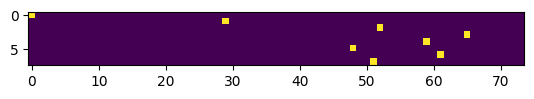

In [86]:
plt.imshow(encod)

In [179]:
for k in range(200):
 encod=F.one_hot(i,num_classes=len(itos)).float() #one_hot doesnt have inbuilt type parameter
 logits=(encod @ w) 
 counts=logits.exp()#sortof equivalent to N matrix
 probs=counts/counts.sum(1,keepdim=True) #these two ops combined is called softmax
 loss=-probs[torch.arange(num),o].log().mean() #nll mean
 print(loss.item()) #forward pass
 w.grad=None 
 loss.backward()
 w.data+=-20*w.grad

2.5145866870880127
2.514538526535034
2.514490842819214
2.514443874359131
2.5143961906433105
2.5143489837646484
2.5143017768859863
2.514254570007324
2.514207601547241
2.514160394668579
2.514113426208496
2.5140671730041504
2.5140204429626465
2.5139737129211426
2.5139269828796387
2.513880729675293
2.5138344764709473
2.5137884616851807
2.513742208480835
2.5136964321136475
2.513650417327881
2.5136046409606934
2.5135586261749268
2.5135130882263184
2.51346755027771
2.5134220123291016
2.5133767127990723
2.513331174850464
2.5132861137390137
2.5132412910461426
2.5131959915161133
2.513150691986084
2.513106107711792
2.5130615234375
2.513016939163208
2.512972116470337
2.512927770614624
2.512883424758911
2.5128390789031982
2.5127947330474854
2.5127506256103516
2.512706756591797
2.512662887573242
2.5126185417175293
2.512575149536133
2.512531280517578
2.5124876499176025
2.512444257736206
2.5124006271362305
2.512357234954834
2.5123140811920166
2.51227068901062
2.5122275352478027
2.5121846199035645
2.51

In [182]:
g=torch.Generator().manual_seed(214597)
for i in range(10):
  out=[]
  ix=0
  while True:
    xenc=F.one_hot(torch.tensor([ix]),num_classes=len(itos)).float()
    logits=xenc @ w #sortof equivalent to N matrix
    counts=logits.exp()
    p=counts/counts.sum(1,keepdim=True) #these two ops combined is called softmax
    
    ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    out.append(itos[ix])
    if(ix==0):
      break
  print(''.join(out))

OparMon SFurin oy Danen he Linve olyas; Sng Fasis Ro tes<S>
Af AKiry9301Wad8Sastusew<S>
Tof Ex<S>
The at, They Pl Pont<S>
Ang t GrthedeOnghe o<S>
Th<S>
Wetald ty2The<S>
Be Mard Lore Thead oul o Lo Honst Lor<S>
Te Krys<S>
Se Lid<S>
